In [1]:
import os
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import LinearSegmentedColormap, ListedColormap, BoundaryNorm
import textwrap
import matplotlib.colorbar as colorbar

from transformers import AutoTokenizer

/capstor/scratch/cscs/jkirchen/daint_210_129_nightly_singleshot/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

def visualize_token_chunks_final(token_ids, effective_k_values, tokenizer,prompt_string=None, max_k=None, output_path="chunk_viz", save_fig=False, fig_size=(12, 11), main_text_fontsize=10, token_count_fontsize=7, cmap_ticks_fontsize=9, prompt_wrap_width=80):
    # 1. Integrity Check
    if len(token_ids) != sum(effective_k_values):
        raise ValueError(f"Mismatch: {len(token_ids)} tokens != {sum(effective_k_values)} sum")

    # # 2. Setup Non-Linear Colormap
    # colors = ["#ffadad", "#ffd6a5", "#caffbf"] 
    # cmap = ListedColormap(colors)
    
    # # Boundaries: [1, 2) is Red, [2, 5) is Yellow, [5, max_k+1) is Green
    # boundaries = [1, 2, 5, max_k + 1]
    # norm = BoundaryNorm(boundaries, cmap.N)

    # 2. Setup Heatmap
    # colors = ["#ffadad", "#ffd6a5", "#caffbf"] 
    colors = ["#ffadad", "#ffd6a5", "#caffbf"] 
    cmap = LinearSegmentedColormap.from_list("chunk_map", colors)

    prompt_color = "#a2d2ff" # Soft Blue for the prompt
    
    max_k = max(effective_k_values) if max_k is None else max_k

    vmin = 1
    vmax = max_k
    print("vmax for colormap:", vmax)
    norm = plt.Normalize(vmin, vmax)

    # 3. Canvas Setup
    fig, ax = plt.subplots(figsize=fig_size)
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.axis('off')

    # Wrapping Parameters
    x_start, y_start = 2, 102
    line_height = 6.5    
    char_width = 1.15    
    curr_x, curr_y = x_start, y_start
    max_x = 98

    # 3. Render Properly Centered Wrapped Prompt Pill
    if prompt_string:
        wrapped_lines = textwrap.wrap(f"{prompt_string}", width=prompt_wrap_width)
        num_lines = len(wrapped_lines)
        
        # Line spacing and box dimensions
        spacing = 3.0
        prompt_box_height = (num_lines * spacing) + 1.0
        prompt_box_width = max_x - x_start
        
        # Draw the pill
        rect = patches.FancyBboxPatch(
            (curr_x, curr_y - prompt_box_height), prompt_box_width, prompt_box_height,
            boxstyle="round,pad=1.0,rounding_size=2.0",
            linewidth=2.5, edgecolor='#333333', facecolor=prompt_color
        )
        ax.add_patch(rect)
        
        # Calculate vertical center of the box
        # Box top is curr_y, bottom is curr_y - prompt_box_height
        box_center_y = curr_y - (prompt_box_height / 2)
        
        # Offset the starting line so the whole block of text is centered on box_center_y
        # The total height of the text block is approximately (num_lines - 1) * spacing
        start_y = box_center_y + ((num_lines - 1) * spacing / 2)
        
        for i, line in enumerate(wrapped_lines):
            ax.text(curr_x + (prompt_box_width / 2), 
                    start_y - (i * spacing), 
                    line, 
                    va='center', ha='center', fontsize=main_text_fontsize, weight='bold', 
                    family='monospace', zorder=3)
        
        # Move cursor below the prompt for the next chunks
        curr_y -= (prompt_box_height + 5)

    current_idx = 0
    for k in effective_k_values:
        chunk_ids = token_ids[current_idx : current_idx + k]
        text = tokenizer.decode(chunk_ids).replace("\n", "↵")
        current_idx += k
        
        box_width = (len(text) * char_width) + 1
        if curr_x + box_width > max_x:
            curr_x = x_start
            curr_y -= line_height
            
        color = cmap(norm(k))
        
        # Rounded Thick Box
        box_height = line_height - 3.0
        rect = patches.FancyBboxPatch(
            (curr_x, curr_y - 2), box_width, box_height,
            boxstyle="round,pad=0.5,rounding_size=1.5",
            linewidth=2.0, edgecolor='#333333', facecolor=color
        )
        ax.add_patch(rect)
        
        ax.text(curr_x + (box_width / 2), curr_y - 0.25, text.strip(), # the space is too much visually 
                va='center', ha='center', fontsize=main_text_fontsize, weight='bold', 
                family='monospace', zorder=3)
        
        # Tiny Token Count (Bottom Right)
        ax.text(curr_x + box_width + 1.1, curr_y - box_height/2 - 1.9, str(k), 
                va='bottom', ha='right', fontsize=token_count_fontsize, weight='bold', 
                color='#444444', family='monospace', zorder=4)  
        
        curr_x += box_width + 2.5 

    # add the averave k value text after all chunks
    avg_k = np.mean(effective_k_values)
    ax.text(curr_x+box_width/2+1 , curr_y-1, f"Avg: {avg_k:.2f}", 
            va='bottom', ha='right', fontsize=main_text_fontsize, weight='bold', 
            color='#222222', family='monospace', zorder=4)

    # # 4. Add Proportional Colorbar
    # cbar_ax = fig.add_axes([0.3, 0.05, 0.4, 0.025])
    # cb = colorbar.ColorbarBase(
    #     cbar_ax, 
    #     cmap=cmap, 
    #     norm=norm, 
    #     boundaries=boundaries, 
    #     spacing='proportional', # THIS makes segments proportional to their size
    #     orientation='horizontal'
    # )

    # 4. Add Colorbar (Legend)
    # We create a new axes area at the bottom of the figure
    cbar_ax = fig.add_axes([0.3, 0.05, 0.4, 0.02]) # [left, bottom, width, height]
    cb = colorbar.ColorbarBase(cbar_ax, cmap=cmap, norm=norm, orientation='horizontal')
    cb.outline.set_linewidth(1.5)
    
    # Set tick labels to show the specific boundary values
    ticks = [1, 3, 5, max_k]
    cb.set_ticks(ticks)
    cb.ax.set_xticklabels([str(t) for t in ticks], fontsize=cmap_ticks_fontsize, fontweight='bold')
    cb.set_label('MTP Chunk Size', fontsize=main_text_fontsize, fontweight='bold', labelpad=10)
    cb.outline.set_linewidth(1.5)

    # ax.set_ylim(curr_y - 15, 105)
    ax.set_ylim(curr_y - 8, 105)

    # make tight
    plt.tight_layout()

    if save_fig:
        print(f"Figure saving to {os.getcwd()}/{output_path}.png and .pdf")
        plt.savefig(f"{output_path}.png", dpi=300, bbox_inches='tight', transparent=True)
        plt.savefig(f"{output_path}.pdf", bbox_inches='tight')
    
    return fig


def match_tok_id_prefix_to_resp(token_ids, response, tokenizer, min_match_len=None, do_retok=False) -> int:
    """
    Matches the token ID prefix to the response string using the provided tokenizer.
    Returns the length of the matched token IDs.
    """
    if tokenizer is None:
        raise ValueError("Tokenizer must be provided for matching token IDs to response.")

    response_tokens = tokenizer.encode(response, add_special_tokens=False)
    match_length = 0

    for tok_id in token_ids:
        if match_length < len(response_tokens) and tok_id == response_tokens[match_length]:
            match_length += 1
        else:
            break

    matched_tok_prefix = token_ids[:match_length]

    if (min_match_len is not None and match_length < min_match_len) or do_retok:
        # print(f"Warning: Matched token prefix length is very short ({match_length}). Possible mismatch.")
        # try bouncing the token ids off of string space and re call the match function
        retokd_token_ids = tokenizer.encode(tokenizer.decode(token_ids,skip_special_tokens=False), add_special_tokens=False)
        # breakpoint()
        return match_tok_id_prefix_to_resp(retokd_token_ids, response, tokenizer)

    return match_length, matched_tok_prefix

def trim_eff_k_toks_to_matched_prefix(eff_k_toks, match_length):

    # effective_k_tokens is a list of nums of tok's predicted at each step
    # so find the palce where cumulative sum reaches match_length using numpy
    eff_k_toks_array = np.array(eff_k_toks)
    cumulative_sum = np.cumsum(eff_k_toks_array)
    trim_index = np.searchsorted(cumulative_sum, match_length, side='right')    
    return eff_k_toks[:trim_index]


In [3]:
#### /capstor/scratch/cscs/jkirchen/singleshot-root/singleshot/outputs/lm_eval_ift_dp/lm_eval_ift_dp_gsm8k_cot_retrorec_gsm8k_mtp_ktoks16_stratconf_adapt@0.9_daint_prod_ift_q3-4b_1N4n_16cdce0f_step-00100160/__capstor__scratch__cscs__jkirchen__singleshot-root__singleshot__outputs__daint_prod_ift_q3-4b__daint_prod_ift_q3-4b_1N4n_16cdce0f__step-00100160/samples_gsm8k_cot_retrorec_2026-01-23T08-29-47.402201.jsonl
# tokenizer = AutoTokenizer.from_pretrained("/capstor/scratch/cscs/jkirchen/singleshot-root/singleshot/outputs/daint_prod_ift_q3-4b/daint_prod_ift_q3-4b_1N4n_16cdce0f/step-00100160")
tokenizer = AutoTokenizer.from_pretrained("jwkirchenbauer/daint_prod_ift_q3-4b_1N4n_16cdce0f_step-00100160")

vmax for colormap: 7
Figure saving to /capstor/scratch/cscs/jkirchen/singleshot-root/singleshot/auto_figures/example_chunk_viz.png and .pdf


/tmp/ipykernel_221877/1935751028.py:144: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


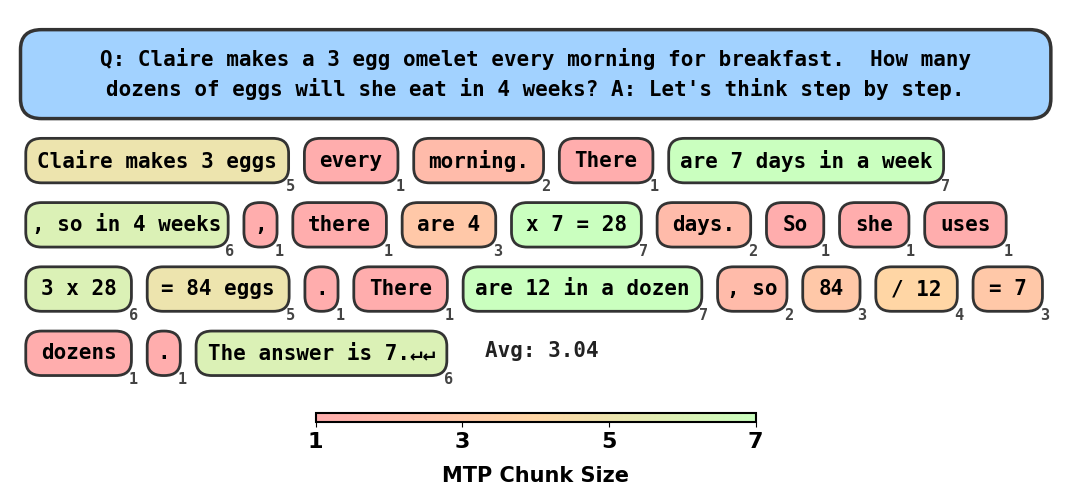

In [ ]:
prompt = None

# response = " James runs 3 sprints 3 times a week, so he runs 3 x 3 = 9 sprints per week. Each sprint is 60 meters, so 9 sprints x 60 meters = 540 meters. The answer is 540.\n\n"
# token_ids = [7801, 8473, 220, 18, 274, 25738, 220, 18, 3039, 264, 2003, 11, 773, 566, 8473, 220, 18, 856, 220, 18, 284, 220, 24, 274, 25738, 817, 2003, 13, 8886, 37849, 374, 220, 21, 15, 20044, 11, 773, 220, 24, 274, 25738, 856, 220, 21, 15, 20044, 284, 220, 20, 19, 15, 20044, 13, 576, 4226, 374, 220, 20, 19, 15, 382, 48, 25, 362, 1874, 315, 220, 16, 15, 15, 1251, 374, 2087, 389, 264, 2070, 8411, 13, 8886, 1697, 21241, 400, 16, 20, 13, 2585, 1753, 3220, 686, 279, 1874, 6530, 304, 2790, 5267, 32, 25, 6771, 594, 1744, 3019, 553, 13, 2619, 525, 220, 16, 15, 15, 1251, 13, 8886, 1697, 21241, 400, 16, 20, 13, 2055, 11, 279, 2790, 3311, 14548, 374, 220, 16, 15, 15, 856, 400, 16, 20, 284, 400, 16, 20, 15, 15, 13, 576, 4226, 374, 220, 16, 20, 15, 15, 382, 48, 25, 362, 1874, 315, 220, 16, 15, 15, 1251, 374, 2087, 389, 264, 2070, 8411, 13, 8886, 1697, 21241, 400, 16, 20, 13, 2585, 1753, 3220, 686, 279, 1874, 6530, 304, 2790, 5267, 32, 25, 6771, 594, 1744, 3019, 553, 3019, 13, 2619, 220, 16, 15, 15, 15, 1251, 13, 8886, 1697, 21241, 400, 16, 20, 13, 2055, 11, 279, 2790, 3311, 14548, 374, 220, 16, 15, 15, 856, 400, 16, 20, 284, 400, 16, 20, 15, 15, 13, 576, 4226, 374, 220, 16, 20, 15, 15, 382, 40, 1865, 264]
# effective_k_values = [5, 1, 1, 4, 2, 4, 7, 4, 2, 7, 1, 2, 1, 1, 4, 1, 5, 1, 5, 2, 1, 2, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 1, 3, 1, 1, 1, 3, 3, 3, 2, 6, 1, 1, 6, 3, 1, 2, 1, 6, 1, 2, 1, 11, 3, 1, 2, 1, 1, 2, 2, 6, 12, 8, 2, 1, 3, 13, 6, 1, 9, 5, 9, 6, 1, 1, 1]

# /capstor/scratch/cscs/jkirchen/singleshot-root/singleshot/outputs/lm_eval_ift_dp/lm_eval_ift_dp_gsm8k_cot_retrorec_gsm8k_mtp_ktoks16_stratconf_adapt@0.9_daint_prod_ift_q3-4b_1N4n_16cdce0f_step-00100160/__capstor__scratch__cscs__jkirchen__singleshot-root__singleshot__outputs__daint_prod_ift_q3-4b__daint_prod_ift_q3-4b_1N4n_16cdce0f__step-00100160/samples_gsm8k_cot_retrorec_2026-01-23T08-29-47.402201.jsonl
prompt = "Q: Claire makes a 3 egg omelet every morning for breakfast.  How many dozens of eggs will she eat in 4 weeks?\nA: Let's think step by step."
response = " Claire makes 3 eggs every morning. There are 7 days in a week, so in 4 weeks, there are 4 x 7 = 28 days. So she uses 3 x 28 = 84 eggs. There are 12 in a dozen, so 84 / 12 = 7 dozens. The answer is 7.\n\n"
token_ids = [42575, 3643, 220, 18, 18805, 1449, 6556, 13, 2619, 525, 220, 22, 2849, 304, 264, 2003, 11, 773, 304, 220, 19, 5555, 11, 1052, 525, 220, 19, 856, 220, 22, 284, 220, 17, 23, 2849, 13, 2055, 1340, 5711, 220, 18, 856, 220, 17, 23, 284, 220, 23, 19, 18805, 13, 2619, 525, 220, 16, 17, 304, 264, 20403, 11, 773, 220, 23, 19, 608, 220, 16, 17, 284, 220, 22, 21935, 13, 576, 4226, 374, 220, 22, 382, 48, 25, 362, 1874, 315, 220, 16, 15, 15, 1251, 3937, 311, 264, 5700, 26705, 13, 220, 21, 15, 315, 1105, 1033, 12598, 11, 323, 279, 2732, 1033, 2841, 13, 2585, 1657, 2841, 3937, 311, 279, 5700, 5267, 32, 25, 6771, 594, 1744, 3019, 553, 13, 2619, 525, 220, 16, 15, 15, 1251, 304, 2790, 13, 220, 21, 15, 315, 1105, 525, 12598, 13, 2055, 279, 2732, 525, 2841, 13, 220, 16, 15, 15, 481, 220, 21, 15, 284, 220, 19, 15, 13, 576, 4226, 374, 220, 19, 15, 382, 48, 25, 362, 1874, 315, 220, 16, 15, 15, 1251, 3937, 311, 264, 5700, 26705, 13, 220, 21, 15, 315, 1105, 1033, 12598, 11, 323, 279, 2732, 1033, 2841, 13, 2585, 1657, 2841, 3937, 311, 279, 5700, 26705, 5267, 32, 25, 6771, 594, 1744, 3019, 553, 3019, 13, 2619, 525, 220, 16, 15, 15, 1251, 304, 2790, 13, 220, 21, 15, 315, 1105, 525, 12598, 13, 576, 2732, 525, 2841, 13, 2055]
effective_k_values = [5, 1, 2, 1, 7, 6, 1, 1, 3, 7, 2, 1, 1, 1, 6, 5, 1, 1, 7, 2, 3, 4, 3, 1, 1, 6, 2, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 6, 1, 2, 1, 4, 3, 3, 3, 1, 5, 3, 3, 2, 3, 1, 1, 1, 1, 1, 1, 1, 8, 3, 1, 1, 6, 2, 1, 1, 2, 1, 1, 4, 2, 6, 5, 8, 6, 2, 1, 3, 10, 3, 3, 2, 3, 1, 1, 2, 1, 1]

#### /capstor/scratch/cscs/jkirchen/singleshot-root/singleshot/outputs/lm_eval_ift_dp/lm_eval_ift_dp_gsm8k_cot_retrorec_gsm8k_mtp_ktoks16_stratconf_adapt@0.6_daint_prod_ift_q3-4b_1N4n_16cdce0f_step-00100160/__capstor__scratch__cscs__jkirchen__singleshot-root__singleshot__outputs__daint_prod_ift_q3-4b__daint_prod_ift_q3-4b_1N4n_16cdce0f__step-00100160/samples_gsm8k_cot_retrorec_2026-01-23T08-04-30.923019.jsonl
# prompt = "Q: In a dance class of 20 students, 20% enrolled in contemporary dance, 25% of the remaining enrolled in jazz dance, and the rest enrolled in hip-hop dance. What percentage of the entire students enrolled in hip-hop dance?\nA: Let's think step by step."
# response = " Total are 20 students students in contemporary dance dance 20% of 20 = 20 * 0.20 = 4 students. Remaining students after 20 - 4 = 16 students. 25% of the remaining students enrolled in jazz dance: 15 * 0.22 = 4 students. The rest enrolled in hip-hop dance: 20 - 4 - 4 = 12 students. Percentage of students in hip-hop dance: 12 / 20 * 100 = 60%. The The answer is 60%.\n\n"
# token_ids = [10657, 525, 220, 17, 15, 4143, 4143, 304, 18706, 15254, 15254, 220, 17, 15, 4, 315, 220, 17, 15, 284, 220, 17, 15, 353, 220, 15, 13, 17, 15, 284, 220, 19, 4143, 13, 89630, 4143, 1283, 220, 17, 15, 481, 220, 19, 284, 220, 16, 21, 4143, 13, 220, 17, 20, 4, 315, 279, 9664, 4143, 36091, 304, 33897, 15254, 25, 220, 16, 20, 353, 220, 15, 13, 17, 17, 284, 220, 19, 4143, 13, 576, 2732, 36091, 304, 18143, 48719, 15254, 25, 220, 17, 15, 481, 220, 19, 481, 220, 19, 284, 220, 16, 17, 4143, 13, 63241, 315, 4143, 304, 18143, 48719, 15254, 25, 220, 16, 17, 608, 220, 17, 15, 353, 220, 16, 15, 15, 284, 220, 21, 15, 14360, 576, 576, 4226, 374, 220, 21, 15, 34332, 48, 25, 362, 51424, 13551, 702, 264, 3084, 315, 220, 16, 15, 20044, 323, 264, 2374, 315, 220, 21, 20044, 13, 3555, 374, 279, 279, 3082, 315, 279, 13551, 5267, 32, 25, 6771, 594, 1744, 3019, 553, 13, 576, 3082, 315, 264, 22756, 374, 16588, 553, 84192, 14806, 25, 12030, 284, 3084, 24768, 2374, 13, 5692, 11, 279, 3084, 374, 220, 16, 15, 20044, 323, 279, 2374, 374, 220, 21, 20044, 13, 2055, 11, 12030, 284, 220, 16, 15, 24768, 24768, 21, 284, 220, 21, 15, 9334, 20044, 13, 576, 4226, 374, 220, 21, 15, 382, 48, 25, 362, 362, 51424, 13551, 702, 264, 3084, 315, 220, 16, 17, 20044, 323, 264, 2374, 315, 220]
# effective_k_values = [8, 3, 1, 11, 2, 8, 1, 2, 9, 4, 1, 7, 1, 3, 1, 3, 6, 5, 1, 1, 1, 7, 6, 6, 3, 1, 1, 8, 8, 8, 5, 2, 1, 1, 8, 6, 11, 2, 2, 8, 7, 1, 4, 2, 1, 2, 14, 2, 7, 5, 1, 8, 1, 5, 14]

# response = 
# token_ids = 
# effective_k_values = 
# response = 
# token_ids = 
# effective_k_values = 

match_length, token_ids = match_tok_id_prefix_to_resp(token_ids, response, tokenizer, do_retok=True)

effective_k_values = trim_eff_k_toks_to_matched_prefix(effective_k_values, match_length)

fig = visualize_token_chunks_final(
    token_ids,
    effective_k_values,
    tokenizer,
    prompt_string=prompt,
    # max_k=16,
    # max_k=7,
    output_path="auto_figures/example_chunk_viz",
    save_fig=True,
    fig_size=(11, 4.5),
    main_text_fontsize=15,
    token_count_fontsize=11,
    cmap_ticks_fontsize=16,
    prompt_wrap_width=75
)
plt.show()
